# Modélisation — Cardio Train (modèle clinique)

Objectif : entraîner et comparer plusieurs modèles de Machine Learning pour prédire la présence
d'une maladie cardiovasculaire (`cardio`) à partir de mesures cliniques (tension, cholestérol,
glucose, IMC, âge, sexe, habitudes de vie).

La logique d'entraînement est centralisée dans `src/train_model.py` — ce notebook l'exécute pas à
pas pour documenter et visualiser la démarche.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from src.feature_engineering import add_bp_category, add_bmi_category
from src.evaluate_model import compute_metrics, compute_confusion_matrix, compute_roc_curve
from src.train_model import build_models

sns.set_style("whitegrid")

## 1. Chargement et feature engineering

Le dataset `processed/cardio_train.csv` est déjà nettoyé (voir `01_data_cleaning.ipynb`). On y ajoute
deux variables dérivées, cliniquement informées :
- `bp_category` : catégorie de pression artérielle (seuils AHA — normale, élevée, hypertension stade 1/2, crise)
- `bmi_category` : catégorie d'IMC (seuils OMS — insuffisance pondérale, normal, surpoids, obésité)

In [2]:
df = pd.read_csv("../../data/processed/cardio_train.csv")
df = add_bp_category(df)
df = add_bmi_category(df)

print(df.shape)
df.head()

(68606, 15)


,age,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,gender_male,BMI,bp_category,bmi_category
0,50,168,62.0,110,80,1,1,0,0,1,0,0,21.967120,2,1
1,55,156,85.0,140,90,3,1,0,0,1,1,1,34.927679,3,3
2,51,165,64.0,130,70,3,1,0,0,0,1,1,23.507805,2,1
3,48,169,82.0,150,100,1,1,0,0,1,1,0,28.710479,3,2
4,47,156,56.0,100,60,1,1,0,0,0,0,1,23.011177,0,1


## 2. Split train / test

Split stratifié 80/20 pour préserver la proportion de patients malades dans les deux échantillons.

In [3]:
TARGET = "cardio"
y = df[TARGET].astype(int)
X = df.drop(columns=[TARGET])
feature_names = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]:,} patients | Test : {X_test.shape[0]:,} patients")
print(f"Prévalence cardio — train : {y_train.mean():.1%} | test : {y_test.mean():.1%}")

Train : 54,884 patients | Test : 13,722 patients
Prévalence cardio — train : 49.5% | test : 49.5%


## 3. Standardisation et entraînement des 4 modèles

Les variables sont standardisées (moyenne 0, écart-type 1) — indispensable pour la régression
logistique, sans impact négatif pour les modèles d'arbres.

Le dataset Cardio Train est déjà équilibré (~50% de cas positifs), donc `class_weight="balanced"`
n'a ici qu'un effet marginal — il devient surtout utile sur le dataset BRFSS (voir son notebook),
mais on garde la même configuration pour les deux afin de comparer des pipelines identiques.

In [4]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

results = {}
fitted_models = {}

for name, model in build_models(scale_pos_weight).items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)[:, 1]

    metrics = compute_metrics(y_test, y_pred, y_proba)
    metrics["confusion_matrix"] = compute_confusion_matrix(y_test, y_pred)
    metrics["roc_curve"] = compute_roc_curve(y_test, y_proba)

    results[name] = metrics
    fitted_models[name] = model

comparison = pd.DataFrame(results).T[["accuracy", "precision", "recall", "f1", "roc_auc"]].astype(float).round(3)
comparison

/Users/kantinfagniart/Documents/Formation/YNOV_Aix/Modules/UF/cardiorisk_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kantinfagniart/Documents/Formation/YNOV_Aix/Modules/UF/cardiorisk_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.732,0.755,0.679,0.715,0.798
Random Forest,0.739,0.765,0.683,0.721,0.807
XGBoost,0.738,0.757,0.695,0.724,0.805
LightGBM,0.740,0.758,0.697,0.726,0.806


## 3 bis. Validation croisée (5-fold stratifiée)

Le score sur un unique split train/test dépend en partie du hasard du découpage. Pour vérifier la
**stabilité** des modèles, on mesure le ROC-AUC en validation croisée 5-fold stratifiée sur le jeu
d'entraînement (le test reste un holdout jamais utilisé). Un écart-type faible entre les folds
indique des performances robustes.

In [5]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_rows = {}
for name, model in build_models(scale_pos_weight).items():
    scores = cross_val_score(model, X_train_s, y_train, cv=cv, scoring="roc_auc")
    cv_rows[name] = {"CV ROC-AUC (moyenne)": scores.mean(), "CV ROC-AUC (écart-type)": scores.std()}

cv_table = pd.DataFrame(cv_rows).T.round(3)
comparison = comparison.join(cv_table)
comparison

/Users/kantinfagniart/Documents/Formation/YNOV_Aix/Modules/UF/cardiorisk_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/kantinfagniart/Documents/Formation/YNOV_Aix/Modules/UF/cardiorisk_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/kantinfagniart/Documents/Formation/YNOV_Aix/Modules/UF/cardiorisk_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/kantinfagniart/Documents/Formation/YNOV_Aix/Modules/UF/cardiorisk_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/kantinfagniart/Documents/Formation/YNOV_Aix/Modules/UF/cardiorisk_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,accuracy,precision,recall,f1,roc_auc,CV ROC-AUC (moyenne),CV ROC-AUC (écart-type)
Logistic Regression,0.732,0.755,0.679,0.715,0.798,0.789,0.002
Random Forest,0.739,0.765,0.683,0.721,0.807,0.797,0.002
XGBoost,0.738,0.757,0.695,0.724,0.805,0.794,0.003
LightGBM,0.740,0.758,0.697,0.726,0.806,0.795,0.002


## 4. Sélection du meilleur modèle

Critère de sélection : **ROC-AUC**, plus robuste que l'accuracy face à un éventuel déséquilibre de
classes et indépendant du seuil de décision choisi.

In [6]:
best_name = comparison["roc_auc"].idxmax()
best_model = fitted_models[best_name]

print(f"Meilleur modèle : {best_name}")
print(f"ROC-AUC = {comparison.loc[best_name, 'roc_auc']:.3f}")

Meilleur modèle : Random Forest
ROC-AUC = 0.807


## 5. Courbes ROC des 4 modèles

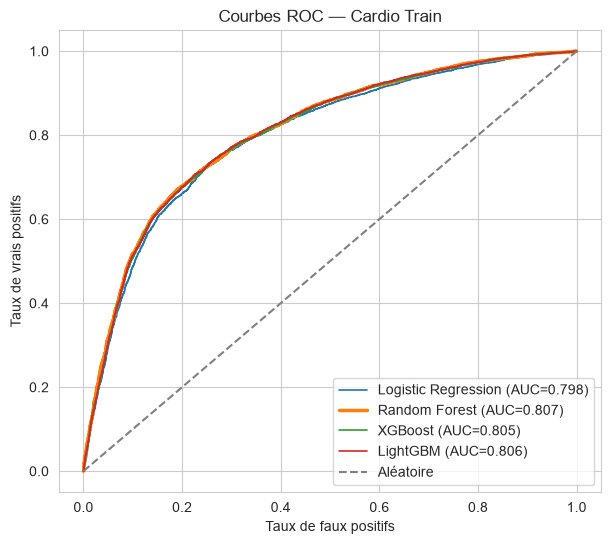

In [7]:
plt.figure(figsize=(7, 6))
for name, metrics in results.items():
    lw = 2.5 if name == best_name else 1.2
    plt.plot(
        metrics["roc_curve"]["fpr"], metrics["roc_curve"]["tpr"],
        label=f"{name} (AUC={metrics['roc_auc']:.3f})", linewidth=lw,
    )

plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Aléatoire")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC — Cardio Train")
plt.legend()
plt.show()

## 6. Matrice de confusion et feature importance du meilleur modèle

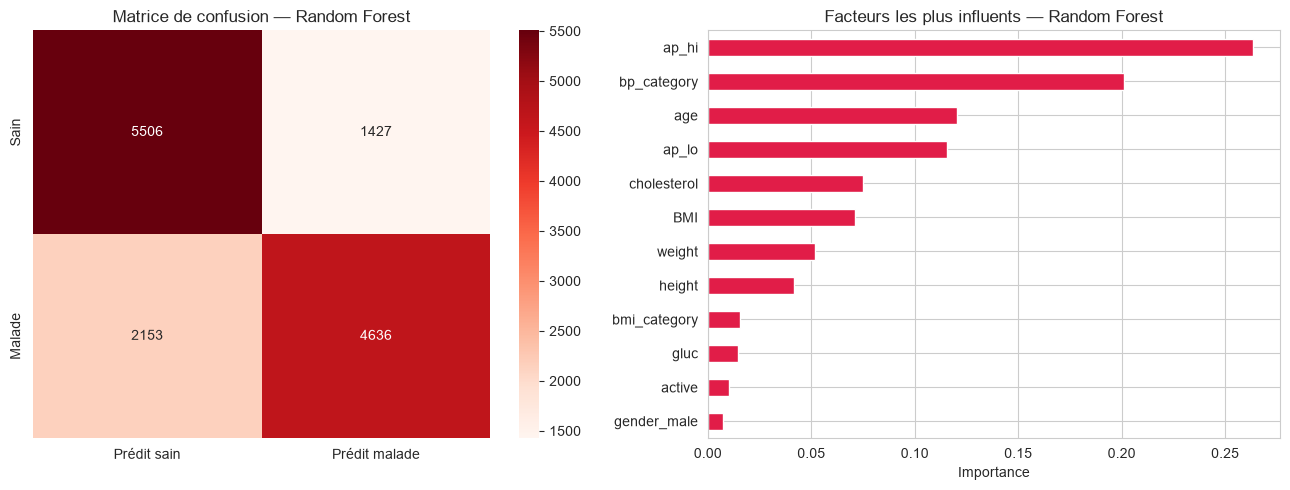

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = results[best_name]["confusion_matrix"]
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Reds", ax=axes[0],
    xticklabels=["Prédit sain", "Prédit malade"], yticklabels=["Sain", "Malade"],
)
axes[0].set_title(f"Matrice de confusion — {best_name}")

if hasattr(best_model, "feature_importances_"):
    importance = pd.Series(best_model.feature_importances_, index=feature_names)
elif hasattr(best_model, "coef_"):
    importance = pd.Series(best_model.coef_[0], index=feature_names)

importance = importance.abs().sort_values(ascending=False).head(12).sort_values()
importance.plot.barh(ax=axes[1], color="#e11d48")
axes[1].set_title(f"Facteurs les plus influents — {best_name}")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

## 7. Sauvegarde des artefacts

Le pipeline complet (identique à celui exécuté ci-dessus) est encapsulé dans
`src.train_model.train_dataset`, appelé pour les deux datasets par `python -m src.train_model`.
On le relance ici pour confirmer que les artefacts persistés (`models/cardio_train/`) sont bien à
jour avec le code de ce notebook.

In [9]:
from src.train_model import DATASETS, train_dataset

original_cwd = os.getcwd()
os.chdir(os.path.abspath("../.."))  # les chemins de train_model.py sont relatifs à la racine du projet
try:
    summary = train_dataset("cardio_train", DATASETS["cardio_train"])
finally:
    os.chdir(original_cwd)


Modèle clinique (Cardio Train) — cardio_train
Logistic Regression    | accuracy=0.732  f1=0.715  roc_auc=0.798  cv_roc_auc=0.789±0.002


Random Forest          | accuracy=0.739  f1=0.721  roc_auc=0.807  cv_roc_auc=0.797±0.002


XGBoost                | accuracy=0.738  f1=0.724  roc_auc=0.805  cv_roc_auc=0.794±0.003


/Users/kantinfagniart/Documents/Formation/YNOV_Aix/Modules/UF/cardiorisk_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/kantinfagniart/Documents/Formation/YNOV_Aix/Modules/UF/cardiorisk_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/kantinfagniart/Documents/Formation/YNOV_Aix/Modules/UF/cardiorisk_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/kantinfagniart/Documents/Formation/YNOV_Aix/Modules/UF/cardiorisk_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/kantinfagniart/Documents/Formation/YNOV_Aix/Modules/UF/cardiorisk_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM               | accuracy=0.740  f1=0.726  roc_auc=0.806  cv_roc_auc=0.795±0.002

→ Meilleur modèle : Random Forest (ROC-AUC = 0.807)


/Users/kantinfagniart/Documents/Formation/YNOV_Aix/Modules/UF/cardiorisk_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kantinfagniart/Documents/Formation/YNOV_Aix/Modules/UF/cardiorisk_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Conclusion

Sur le dataset clinique (données objectives, cohorte équilibrée), les 4 modèles obtiennent des
performances proches (ROC-AUC entre 0.80 et 0.81) : la marge de progression est faible sur ce
dataset propre et de taille modeste. **Random Forest** l'emporte de justesse.

La feature importance confirme des résultats cliniquement attendus : la **pression artérielle**
(`ap_hi`, et la variable dérivée `bp_category`) domine largement, suivie de l'**âge** et de l'**IMC**
— cohérent avec les facteurs de risque cardiovasculaire connus. L'analyse détaillée de ces facteurs
et leur interprétation se poursuivent dans `04_interpretation.ipynb`.